<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [18]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path
from datetime import datetime

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [ ]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [4]:
7*53

371

In [ ]:
n_regions = 3 
T = 96  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N = np.array([1100000, 440000, 680000])
## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7     # 1/infectious period per week (Ebola: ~7 days)

sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 1, 1])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([10,10,10])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.22626748e+01, 8.09196051e+00, 7.01733177e+00],
       [1.86237981e+01, 1.81577564e+01, 1.45945881e+01],
       [2.61670377e+01, 3.14526157e+01, 2.29851596e+01],
       [3.65788403e+01, 5.39270456e+01, 3.57252426e+01],
       [5.11155336e+01, 9.24161051e+01, 5.54861709e+01],
       [7.14271866e+01, 1.58367613e+02, 8.61732420e+01],
       [9.98092346e+01, 2.71370192e+02, 1.33829639e+02],
       [1.39467818e+02, 4.64963971e+02, 2.07836353e+02],
       [1.94882079e+02, 7.96545050e+02, 3.22755933e+02],
       [2.72309180e+02, 1.36423166e+03, 5.01188803e+02],
       [3.80489043e+02, 2.33545747e+03, 7.78195544e+02],
       [5.31627392e+02, 3.99506564e+03, 1.20813209e+03],
       [7.42766030e+02, 6.82509057e+03, 1.87518577e+03],
       [1.03769103e+03, 1.16338765e+04, 2.90954794e+03],
       [1.44958625e+03, 1.97556967e+04, 4.51207310e+03],
       [2.02471612e+03, 3.33326056e+04, 6.99148189e+03],
       [2.82752287e+03, 5.56363

## Add Noise

In [9]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [10]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,10.000000,0.000000,0,4.499989e+06,...,10.000000,0.000000,0,6.799989e+06,1.000000,10.000000,0.000000,10.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,18.612876,10.665116,11.597559,22.262675,12.262675,8,4.499966e+06,...,18.091961,8.091961,12,6.799970e+06,13.467139,7.738984,9.278348,17.017332,7.017332,9
2,2013-12-30,2,1.149993e+07,26.453578,14.586345,26.300128,40.886473,18.623798,19,4.499935e+06,...,36.249717,18.157756,26,6.799946e+06,21.942338,11.347891,20.264029,31.611920,14.594588,9
3,2013-12-31,3,1.149990e+07,37.008198,20.352310,46.701201,67.053511,26.167038,16,4.499883e+06,...,67.702333,31.452616,21,6.799911e+06,34.166770,17.566403,37.030676,54.597079,22.985160,31
4,2014-01-01,4,1.149984e+07,51.718371,28.436932,75.195419,103.632351,36.578840,37,4.499795e+06,...,121.629378,53.927046,54,6.799857e+06,53.071222,27.277061,63.045261,90.322322,35.725243,26


# Plot the results

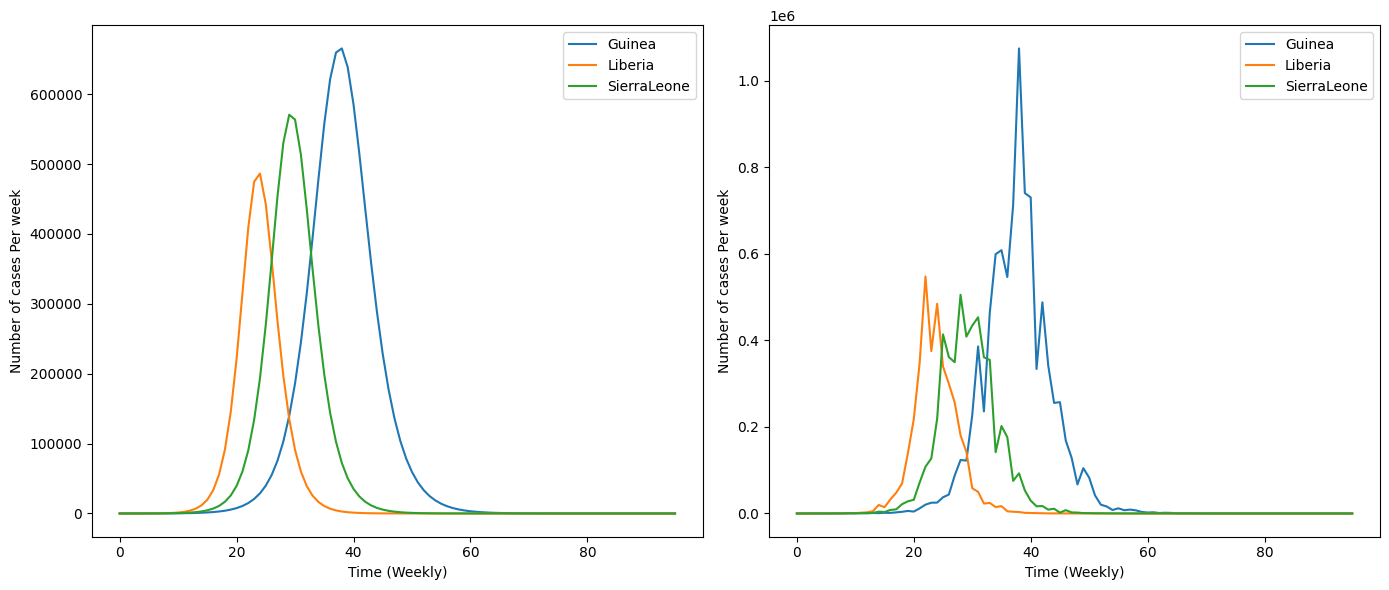

In [11]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [12]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

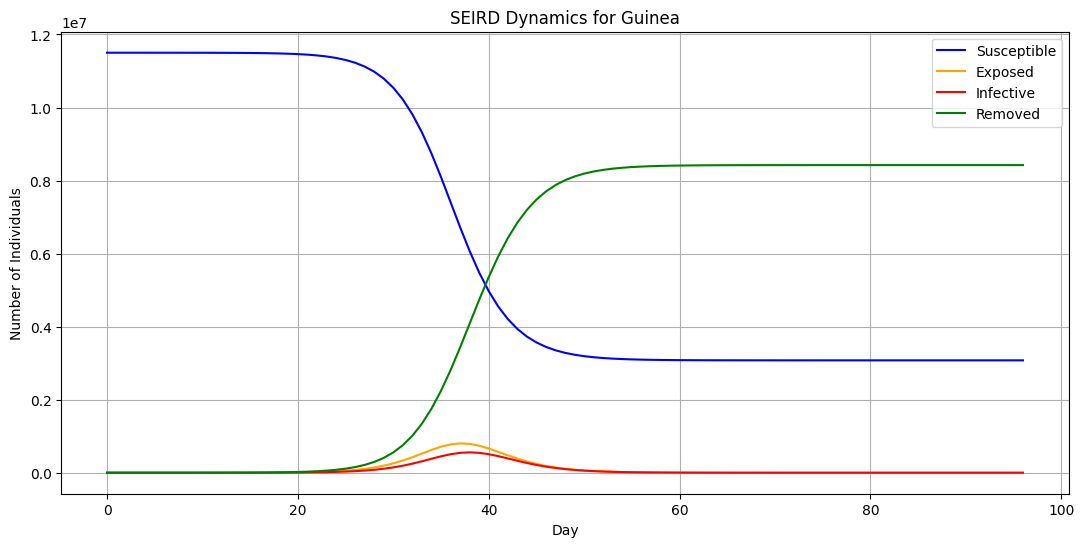

In [13]:
plot_SEIR(raw, 'Guinea')

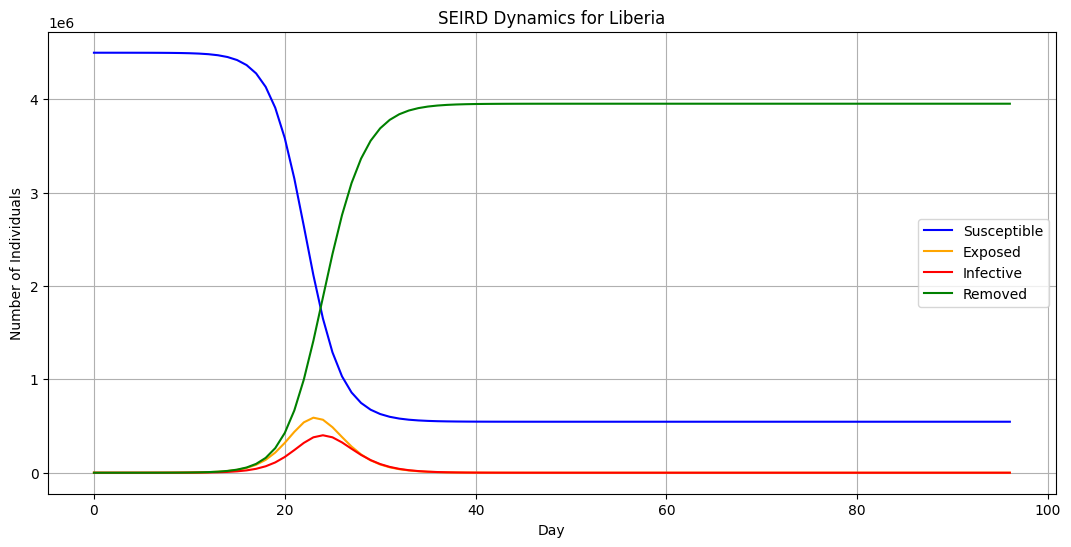

In [14]:
plot_SEIR(raw, 'Liberia')

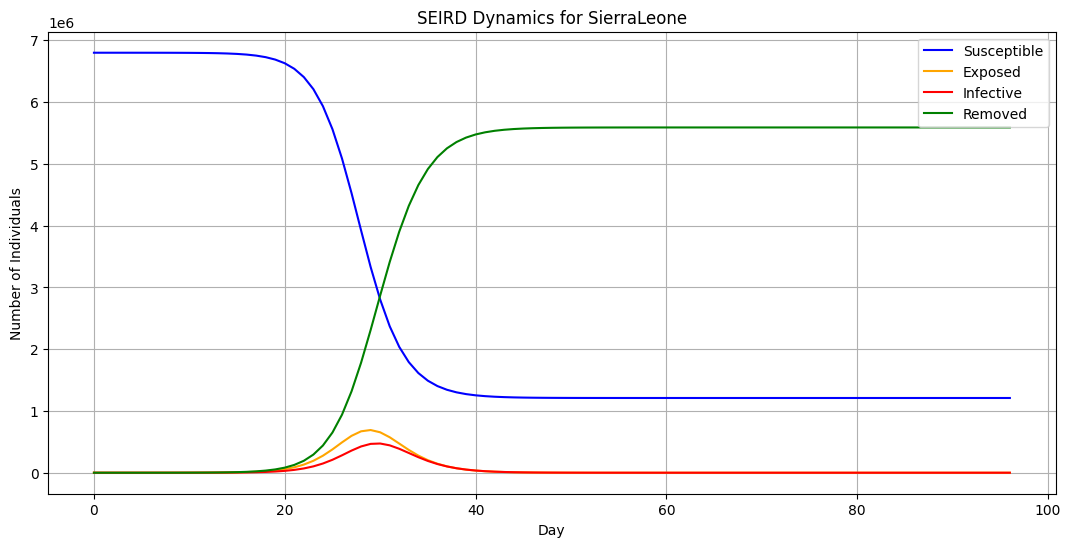

In [15]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [16]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = (1/8.5)*7             #incubation rate per week
gamma = (1/6)*7 

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0 - e0
r0 = [0, 0, 0]
c0 = [10, 10, 10]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [17]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma,
    'gamma_value': gamma,
    "reporting_rate": reporting_rate
}

seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [ ]:
# %run fit_single.py
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 14:32 Iteration: 1900 / 2000 [ 95%]  (Sampling)
































































chain 1 |██████████| 58:40 Sampling completed                       
chain 2 |██████████| 58:40 Sampling completed                       
chain 3 |██████████| 58:40 Sampling completed                       
chain 4 |██████████| 58:40 Sampling completed                       

NameError: name 'fit' is not defined

In [20]:
# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/guinea_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit1.save_csvfiles(dir=output_dir)
print(f"\nFit for all Patches saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for all Patches completed. Check 'output/' directory.")


Fit for all Patches saved to: outputs/guinea_20250608_072749
Fits for all Patches completed. Check 'output/' directory.


In [24]:
# %run fit_single.py
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/Liberia_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit2.save_csvfiles(dir=output_dir)
print(f"\nFit Liberia saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Liberia completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 07:43 Iteration: 1900 / 2000 [ 95%]  (Sampling)































































chain 1 |██████████| 34:58 Sampling completed                       
chain 2 |██████████| 34:58 Sampling completed                       
chain 3 |██████████| 34:58 Sampling completed                       
chain 4 |██████████| 34:58 Sampling completed                       

                                                                                                                                                                                                                                                                                                                                

Fit Liberia saved to: outputs/Liberia_20250608_080629
Fits Liberia completed. Check 'output/' directory.


In [48]:
# %run fit_single.py
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/Sierraleone_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit3.save_csvfiles(dir=output_dir)
print(f"\nFit Sierra Leone saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Sierra Leone completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 01:01 Iteration: 1900 / 2000 [ 95%]  (Sampling)































































chain 1 |██████████| 43:19 Sampling completed                       
chain 2 |██████████| 43:19 Sampling completed                       
chain 3 |██████████| 43:19 Sampling completed                       
chain 4 |██████████| 43:19 Sampling completed                       



Fit Sierra Leone saved to: outputs/Sierraleone_20250608_090040
Fits Sierra Leone completed. Check 'output/' directory.


In [58]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('outputs/guinea_20250608_072749/simple_seir-*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('outputs/Liberia_20250608_080629/simple_seir-*_*.csv')
# fit2 = from_csv('outputs/liberia_20250608_055540/simple_seir-*_*.csv')
print("Liberia fit loaded")

# # Load Sierra Leone fit
# fit3 = from_csv('outputs/sierraleone_20250608_060434/simple_seir-*_*.csv')
fit3 = from_csv('outputs/Sierraleone_20250608_090040/simple_seir-*_*.csv')
print("Sierra Leone fit loaded")

Guinea fit loaded
Liberia fit loaded
Sierra Leone fit loaded


In [51]:
print(fit3.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.07, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma, beta, gamma, y[3,1], y[4,1], y[5,1], y[6,1], y[7,1], y[8,1], y[9,1], y[11,1], y[12,1], y[13,1], y[14,1], y[15,1], y[16,1], y[17,1], y[18,1], y[19,1], y[20,1], y[21,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[34,1], y[35,1], y[36,1], y[37,1], y[38,1], y[39,1], y[40,1], y[41,1], y[42,1], y[43,1], y[44,1], y[45,1], y[46,1], y[47,1], y[48,1], y[49,1], y[50,1], y[51

In [55]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.791624,0.002464,0.100711,0.096935,0.644763,0.783455,0.971937,1766.37,1848.59,1.00121
beta,1.662360,0.004671,0.175416,0.172790,1.410400,1.645190,1.976160,1443.77,1919.48,1.00191
gamma,0.824343,0.003195,0.124287,0.123312,0.641127,0.813198,1.038350,1510.49,1999.95,1.00157
recovery_time,1.240180,0.004742,0.183580,0.186333,0.963063,1.229710,1.559750,1510.47,1999.95,1.00232
incubation_period,1.283070,0.003801,0.158743,0.158460,1.028870,1.276390,1.550960,1766.32,1848.59,1.00121
R0,2.033120,0.003474,0.144150,0.140765,1.821370,2.017080,2.297830,1807.00,1879.53,1.00183
phi,9.958410,0.038994,1.776700,1.679450,7.311400,9.802670,13.196600,2103.51,2182.27,1.00262
phi_inv,0.103692,0.000427,0.019057,0.017618,0.075777,0.102013,0.136773,2103.51,2182.27,1.00262


In [56]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.546410,0.660316,1.048510,0.252379,0.808047,1.066600,3.812230,7.30627,2000.000,1.52362
beta,1.849360,0.496394,0.723761,0.320316,0.614902,2.139300,2.603460,7.30685,2000.000,1.52876
gamma,0.733667,0.290804,0.430473,0.232401,0.024628,0.885555,1.224960,7.31984,2000.000,1.52964
recovery_time,9.927700,10.876700,15.608600,0.272305,0.816352,1.129240,40.604200,7.31983,2000.000,1.52998
incubation_period,0.842083,0.205593,0.317881,0.240982,0.262313,0.937560,1.237550,7.30626,2000.000,1.52362
R0,7.580430,6.401180,9.140010,0.394720,2.016940,2.451570,25.062200,7.25235,2000.000,1.52882
phi,7.477410,0.451269,1.887020,1.832890,4.656600,7.342760,10.775700,38.09960,148.113,1.07716
phi_inv,0.143125,0.010282,0.040306,0.034079,0.092801,0.136188,0.214749,38.09970,148.113,1.07716


In [59]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.775767,0.169397,0.272637,0.218225,0.365757,0.821374,1.17197,7.25206,2000.00,1.52931
beta,1.822520,0.244526,0.419558,0.386936,1.212310,1.859950,2.48715,7.42295,2000.00,1.53205
gamma,0.716141,0.263358,0.404970,0.267912,0.075985,0.825554,1.24166,7.29915,2000.00,1.53004
recovery_time,3.921370,3.427190,4.886420,0.352213,0.805377,1.211300,13.16060,7.29917,2000.00,1.53039
incubation_period,1.520810,0.479197,0.694633,0.304459,0.853264,1.217470,2.73405,7.25206,2000.00,1.52944
R0,5.473730,3.995910,5.690230,0.367462,1.895980,2.288100,16.14520,7.26742,2000.00,1.52998
phi,7.261240,0.077589,1.461870,1.420300,5.066360,7.139610,9.87999,1046.74000,1926.18,1.01421
phi_inv,0.143490,0.000936,0.029877,0.027995,0.101215,0.140064,0.19738,1046.74000,1926.18,1.01421


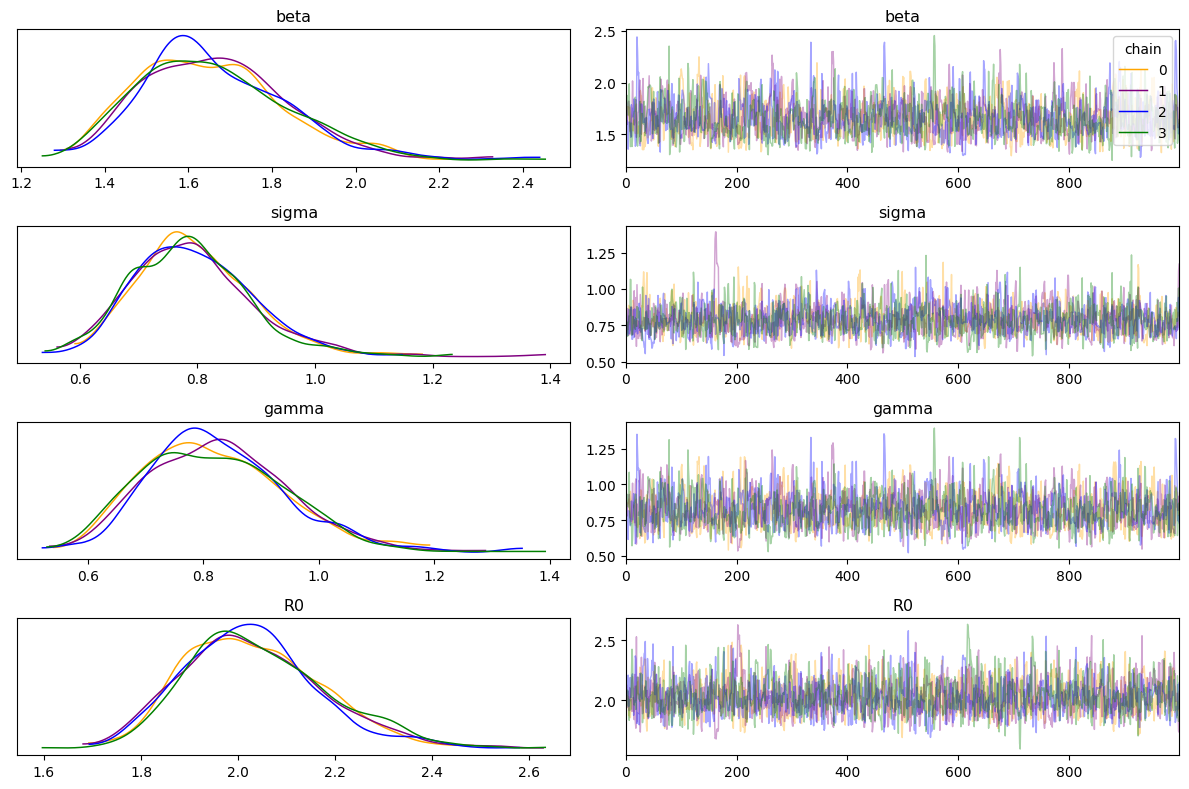

In [60]:
## trace plots
axes = az.plot_trace(fit1, 
              var_names=["beta", "sigma", "gamma", "R0"],
            #   figsize=(12, 8),
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

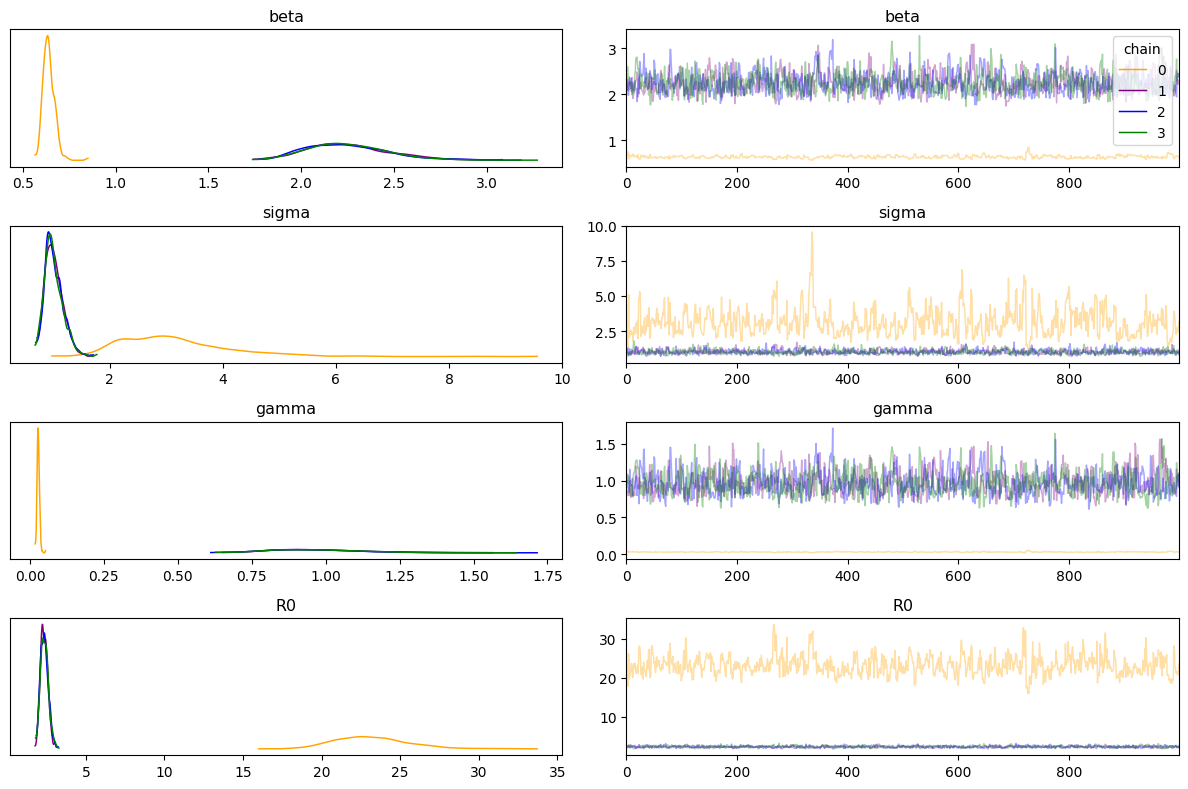

In [61]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

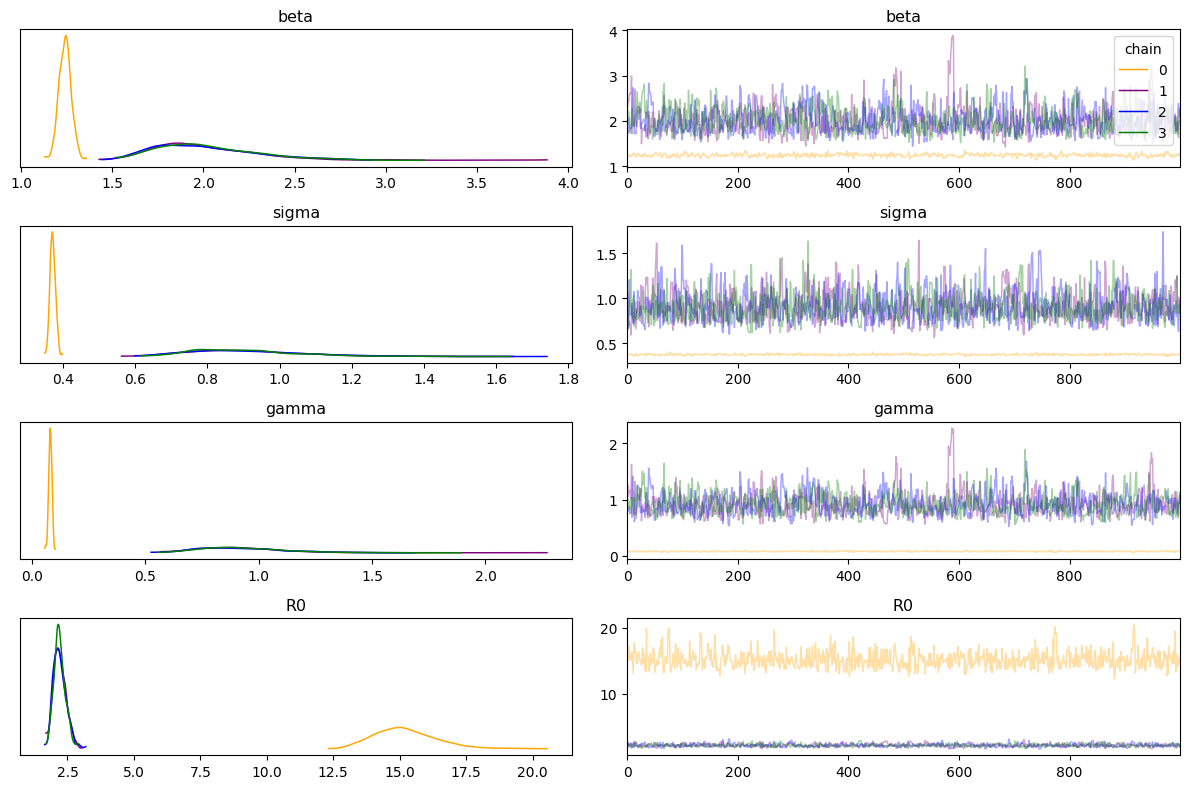

In [62]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
# post_guinea = fit1.draws_pd()
# post_liberia = fit2.draws_pd()
# post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [ ]:
# fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],16.59500,0.129185,7.957190,7.4130,6.0,15.0,32.00,3862.82,3955.72,1.00016
pred_incidence[2],23.28900,0.172256,10.721500,10.3782,9.0,22.0,43.00,3910.84,3833.26,1.00086
pred_incidence[3],33.51250,0.240548,14.552000,13.3434,13.0,32.0,61.00,3775.80,3830.32,1.00112
pred_incidence[4],47.04950,0.349578,20.677300,19.2738,19.0,44.0,84.05,3615.36,3892.30,1.00043
pred_incidence[5],68.36000,0.482790,29.019400,26.6868,28.0,65.0,122.00,3603.69,3748.39,1.00013
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.02925,NaN,0.172922,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[93],0.02600,NaN,0.160719,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[94],0.02075,NaN,0.144307,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[95],0.01500,NaN,0.123608,0.0000,0.0,0.0,0.00,NaN,NaN,NaN


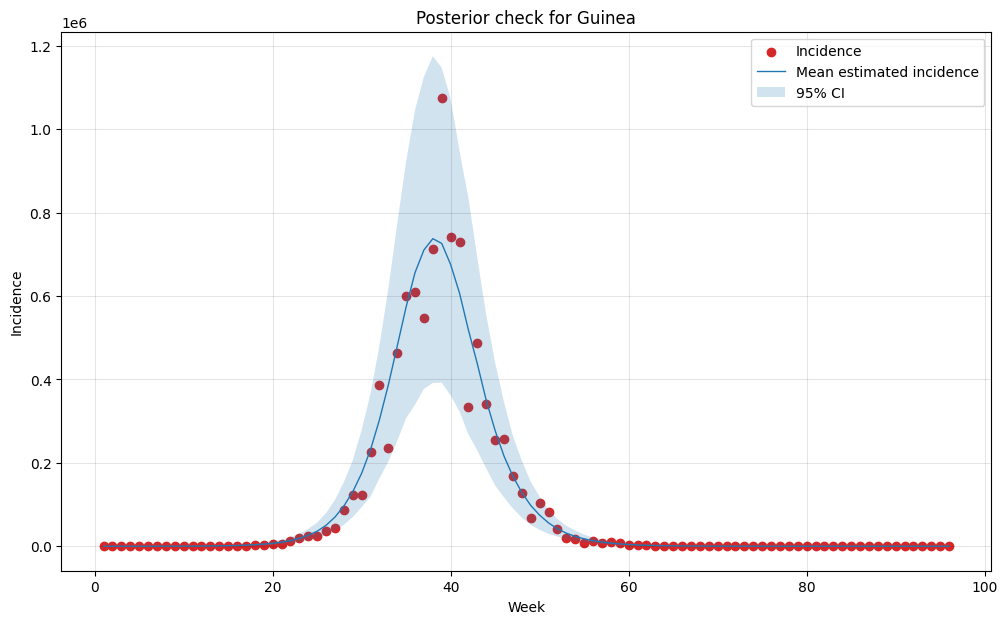

In [63]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

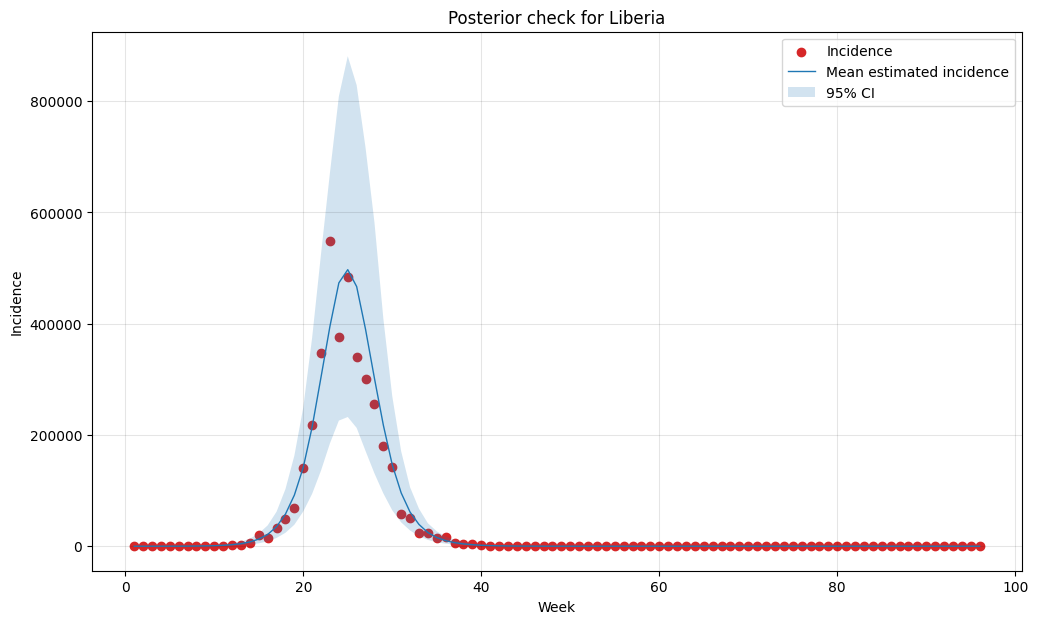

In [64]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

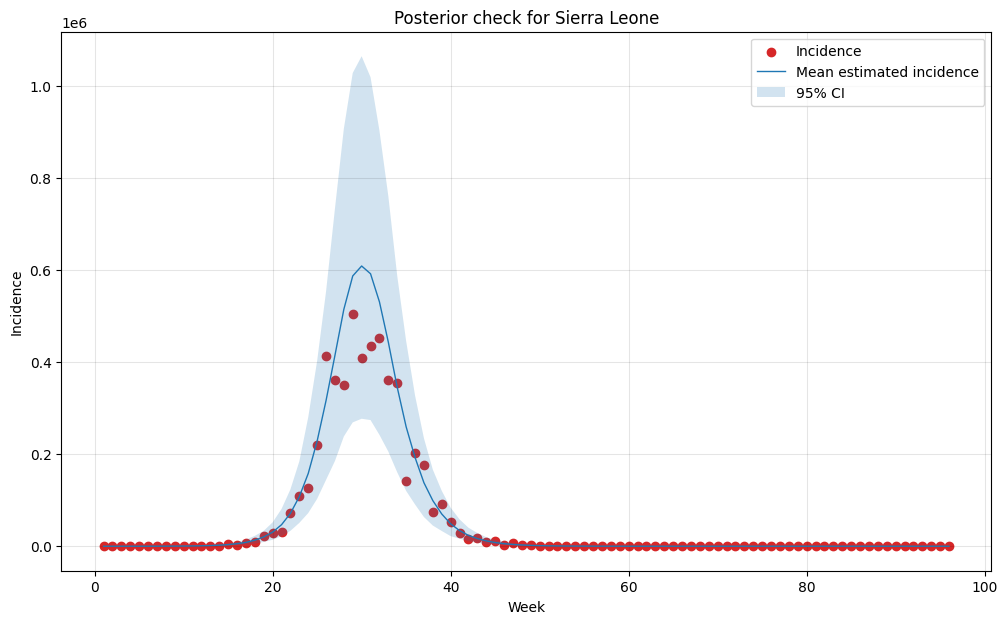

In [65]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [66]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = 1/8.5*7 #incubation rate per week
gamma = 1/13*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec,
    'incubation_period': incu}

t2 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

t3 = {'beta':beta[2],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec,
    'incubation_period': incu}

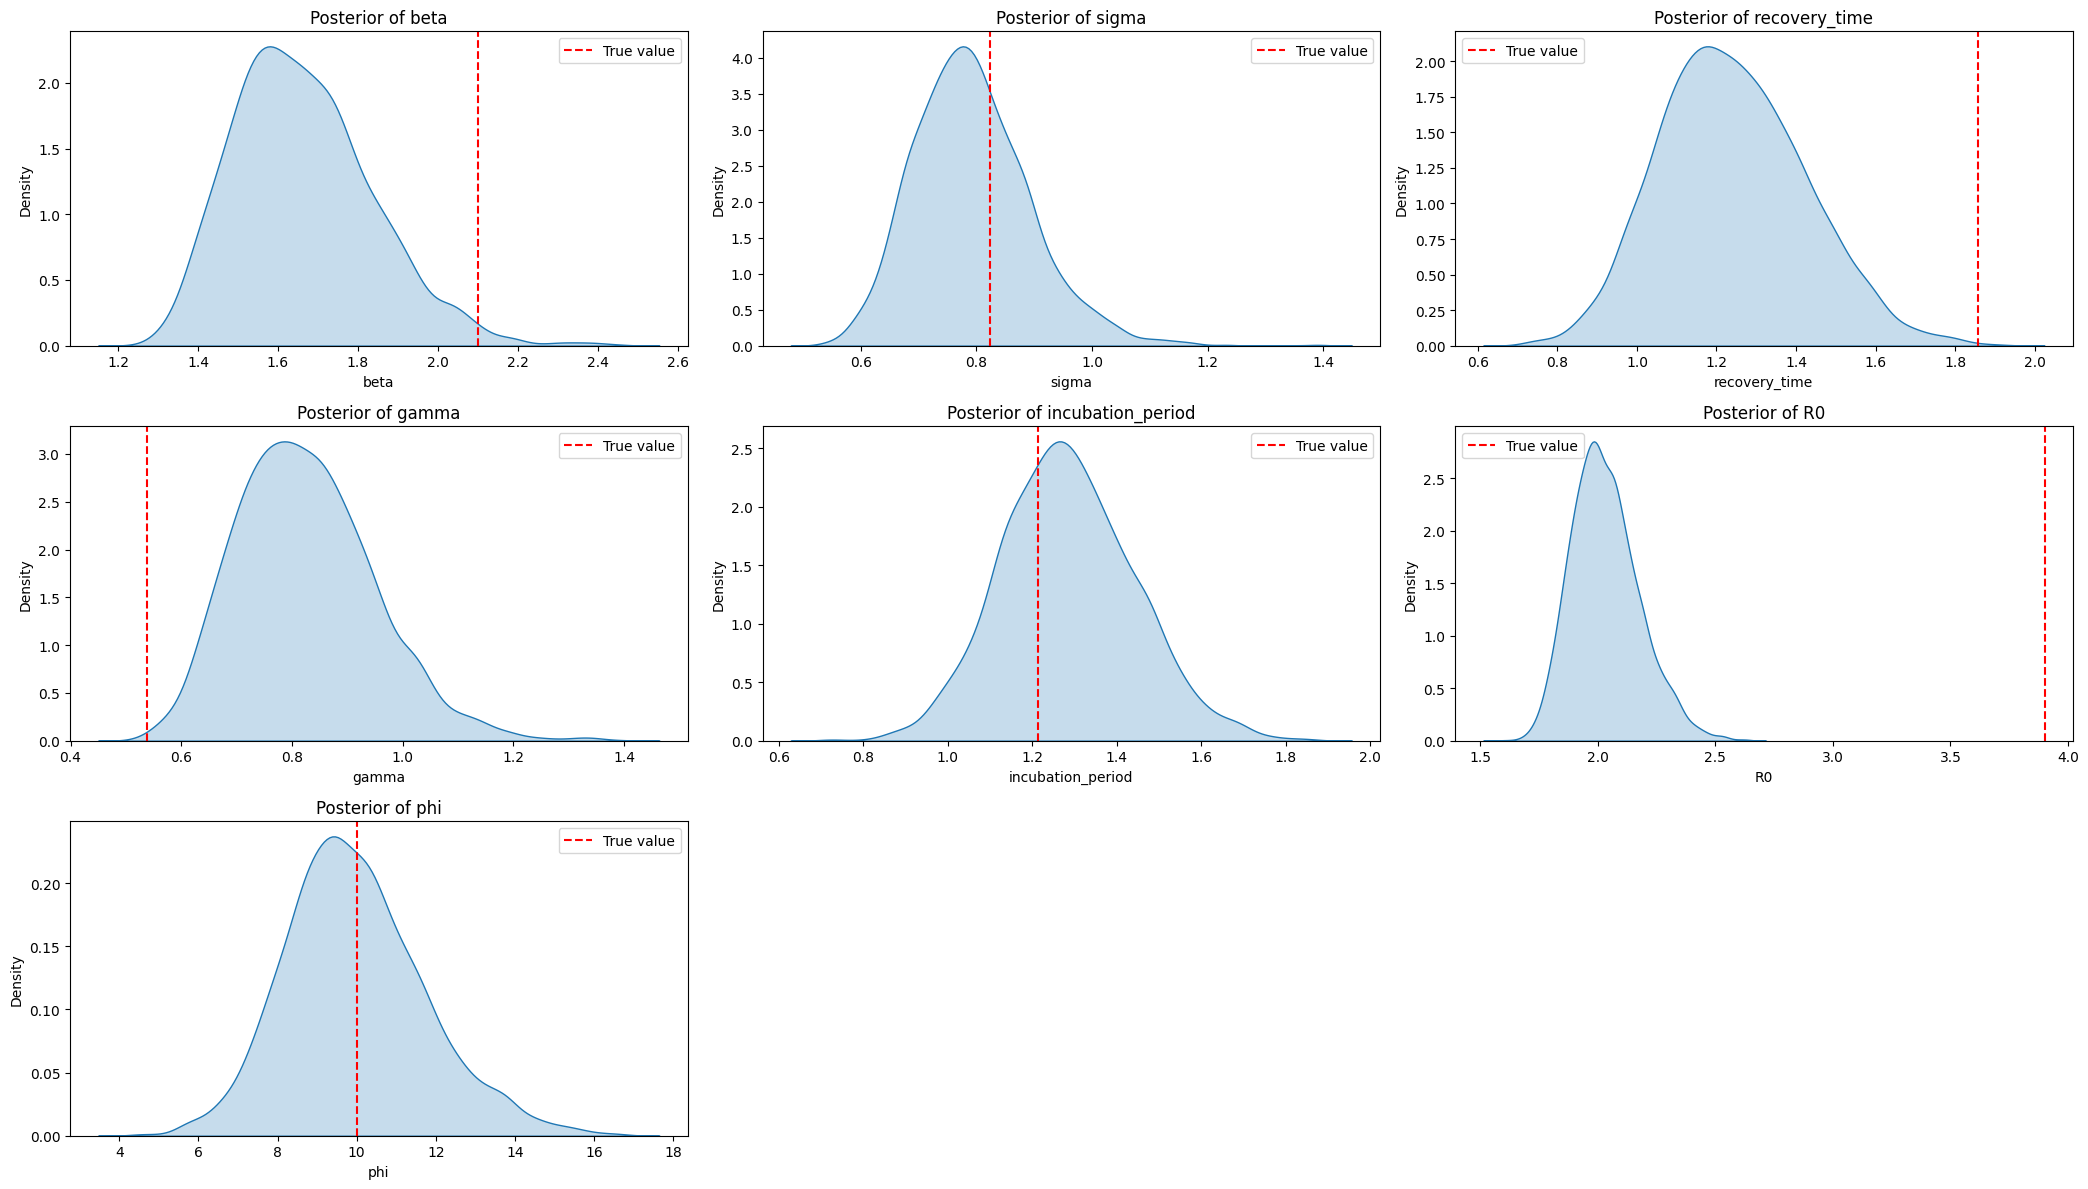

In [67]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1)

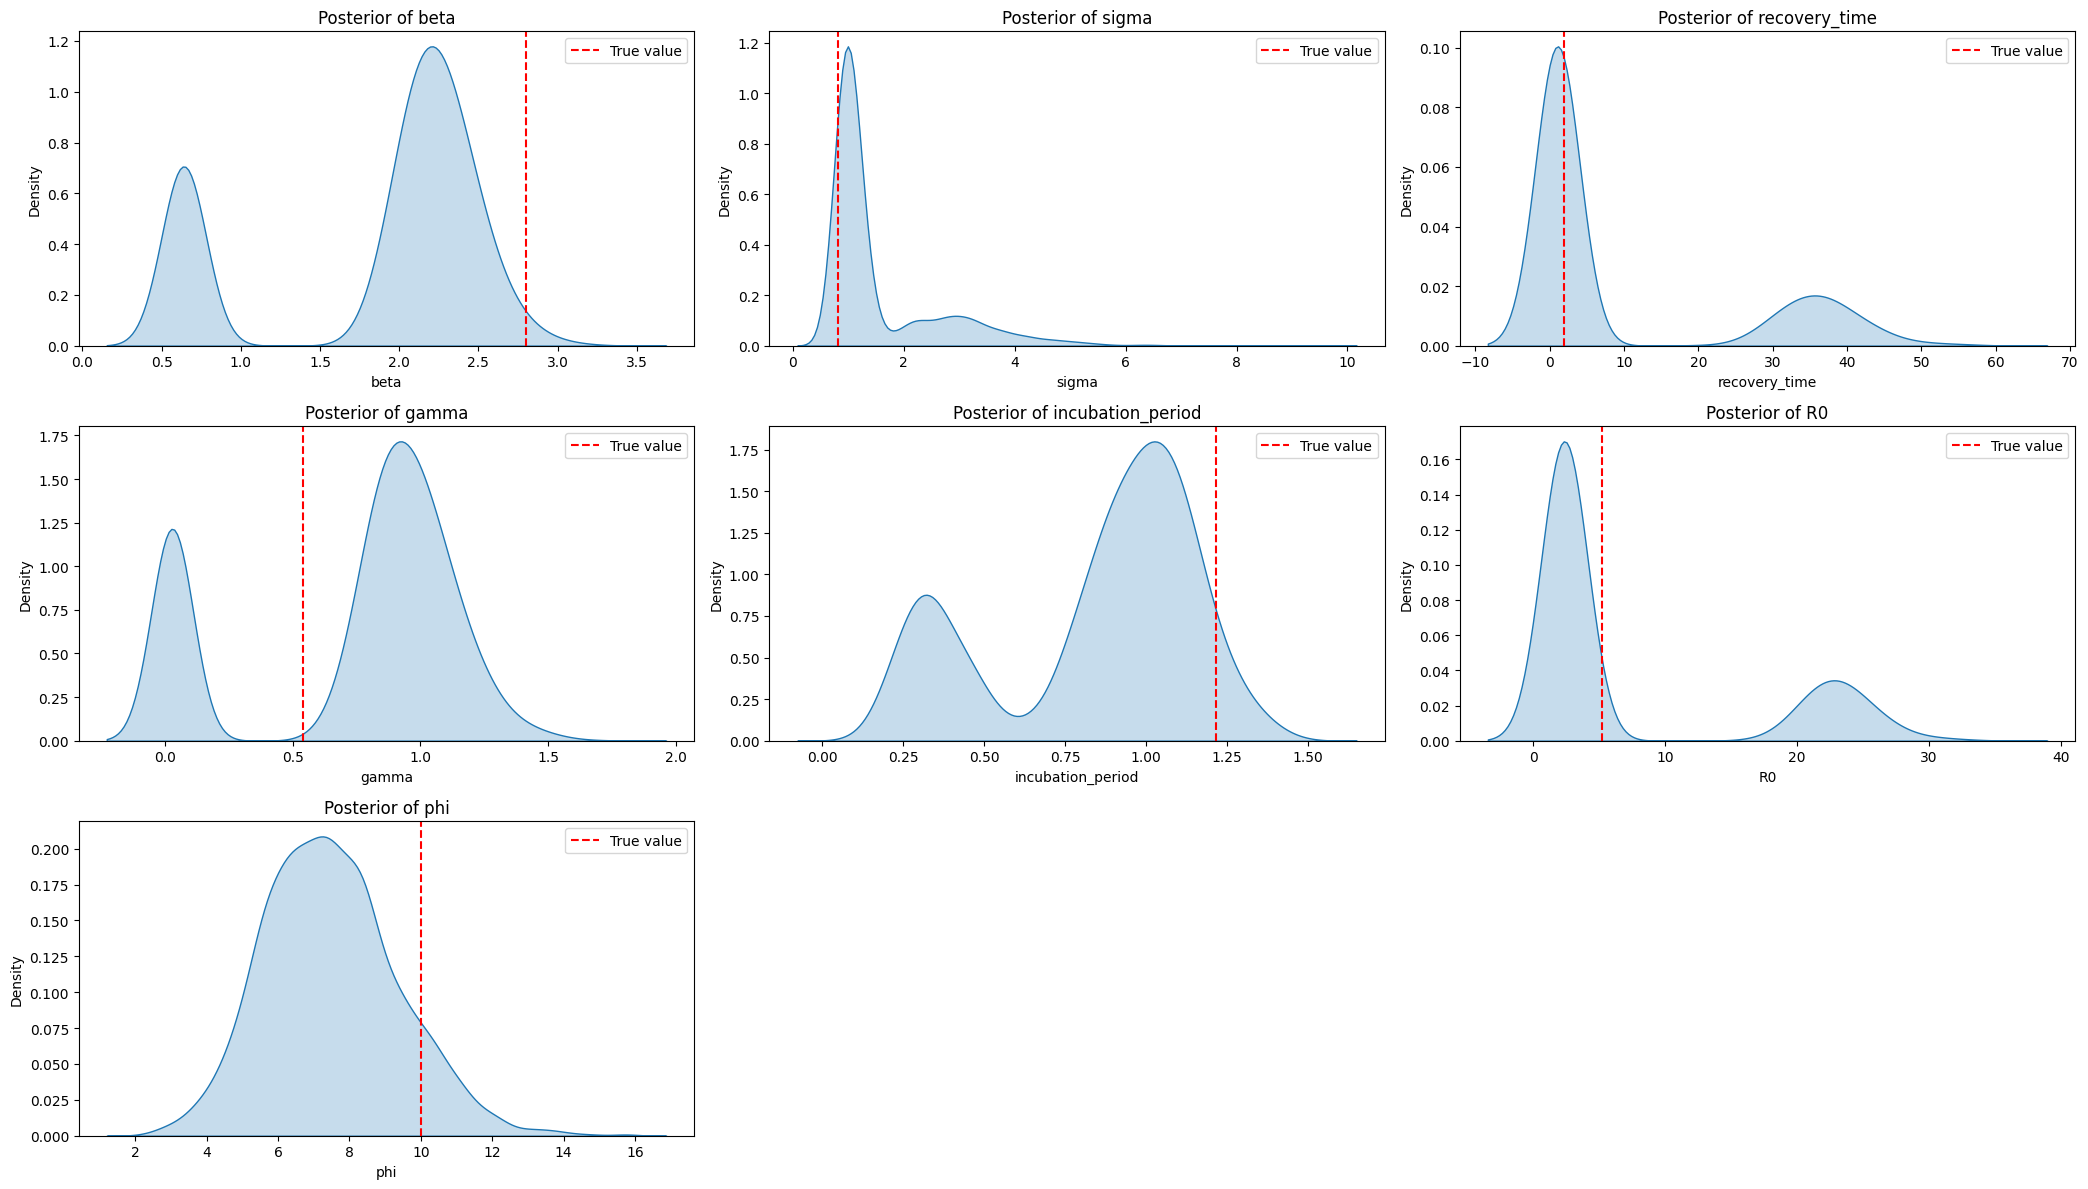

In [68]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2)

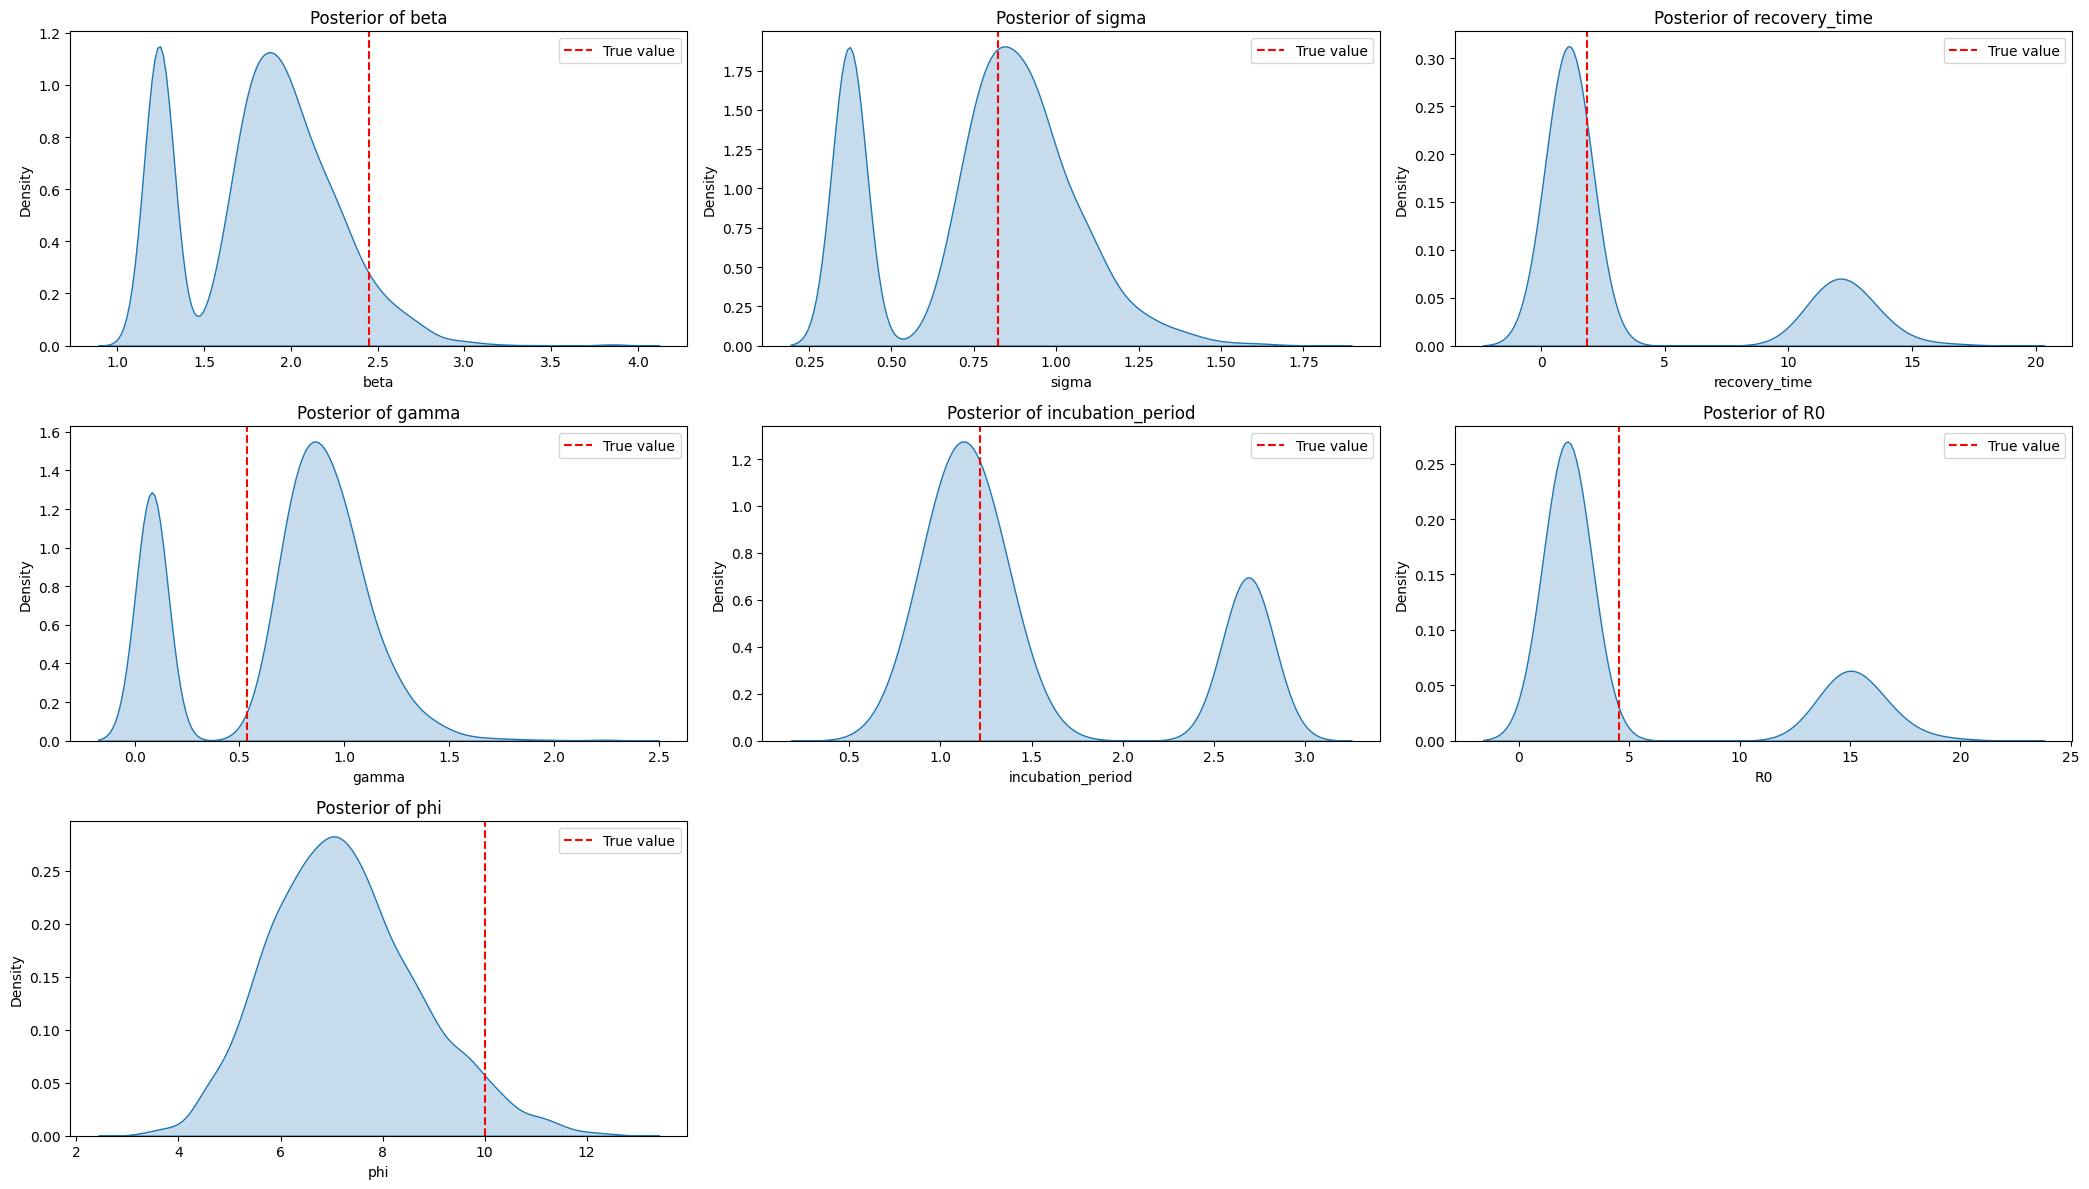

In [69]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3)

## Plot SEIR Compartments

In [70]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

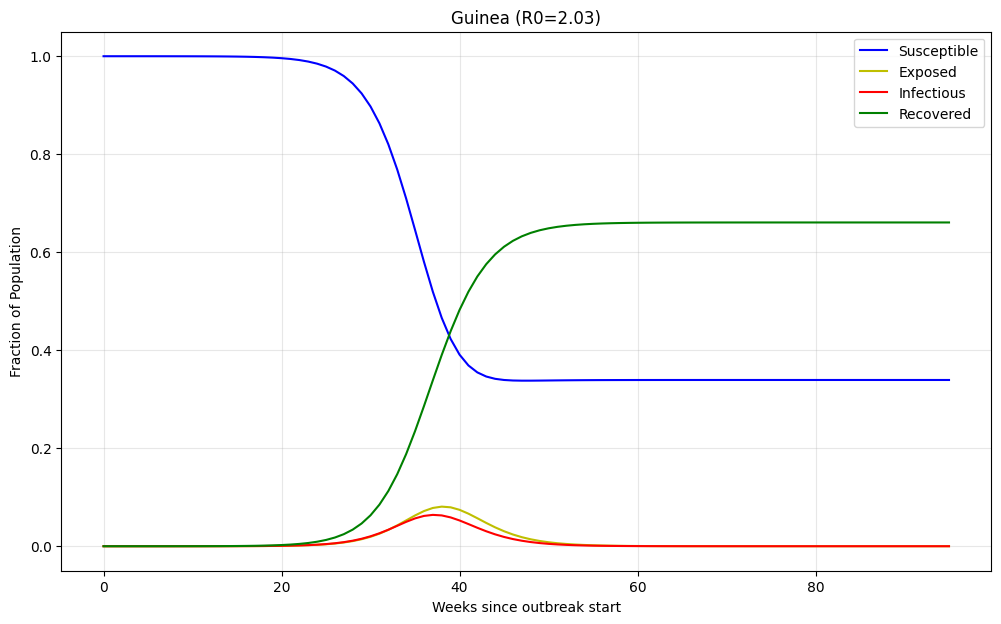

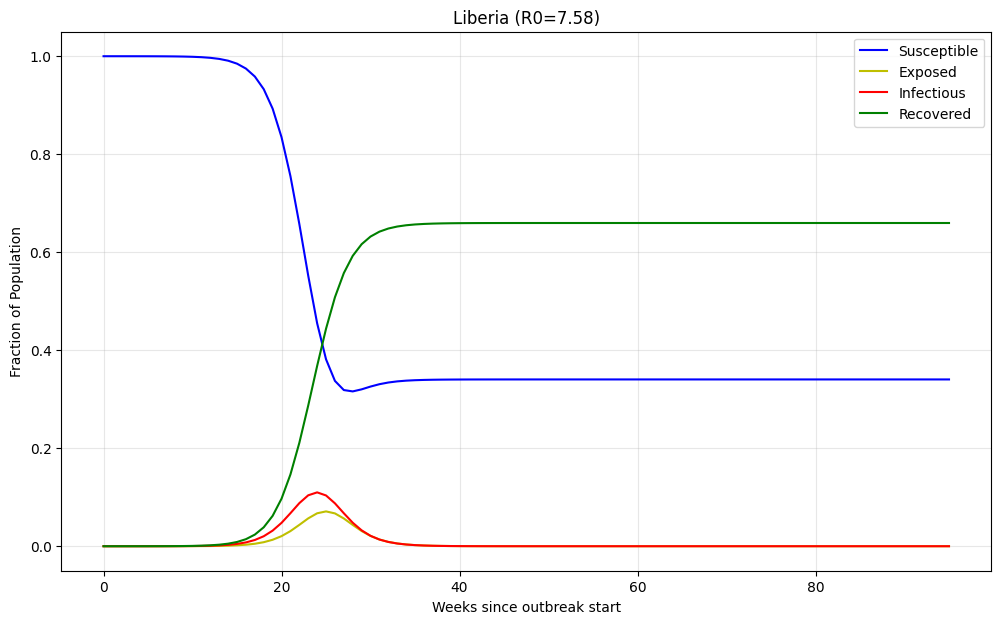

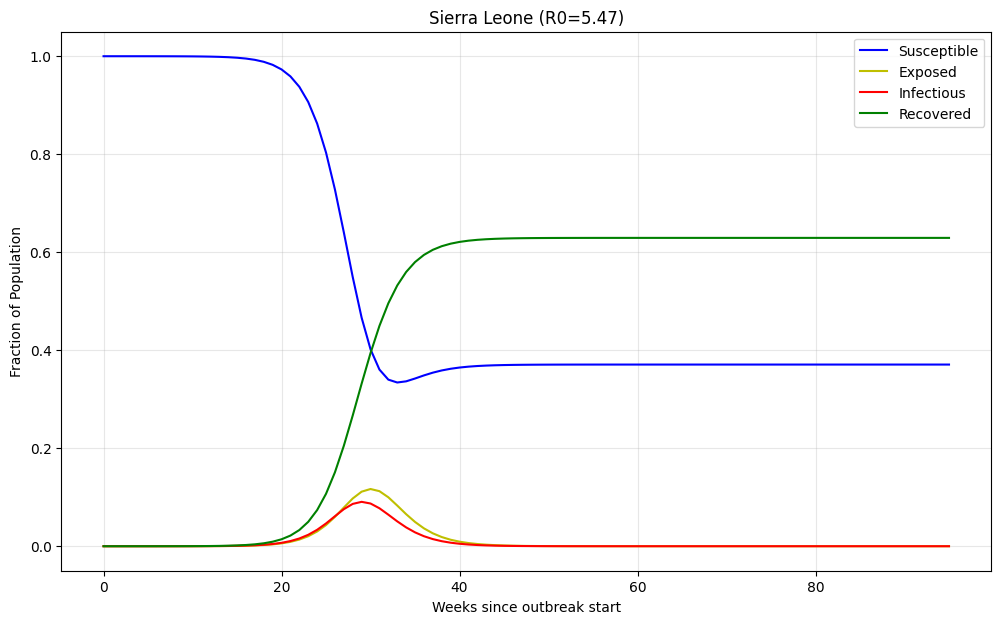

In [72]:
plot_compartment(fit1, country_idx=0)
plot_compartment(fit2, country_idx=1)
plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [32]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.tail()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
91,0,0,0
92,0,0,0
93,0,0,0
94,0,0,0
95,0,0,0


In [ ]:
# %run fit_multi.py


In [74]:
from cmdstanpy import from_csv

# Load Guinea fit
fit_multi_model = from_csv('outputs/all_Patches_20250608_012838/mult-*_*.csv')
print("All fit loaded")
print(fit_multi_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  beta[1], beta[2], beta[3], sigma, gamma, phi_inv, y[2,2,1], y[3,2,1], y[2,3,1], y[3,3,1], y[2,4,1], y[3,4,1], y[2,5,1], y[3,5,1], y[1,6,1], y[2,6,1], y[3,6,1], y[1,7,1], y[2,7,1], y[3,7,1], y[1,8,1], y[2,8,1], y[3,8,1], y[1,9,1], y[2,9,1], y[3,9,1], y[1,10,1], y[2,10,1], y[3,10,1], y[1,11,1], y[2,11,1], y[3,11,1], y[1,12,1], y[2,12,1], y[3,12,1], y[1,13,1], y[2,13,1], y[3,13,1], y[1,14,1], y[2,14,1], y[3,14,1], y[1,15,1], y[2,15,1], y[1,16,1], y[2,16,1], y[1,17,1], y[2,17,1], y[3,17,1], y[1,18,1], y[2,18,1], y[3,18,1], y[1,19,1], y[2,19,1], y[3,19,1], y[1,20,1], y[2,20,1], y[3

In [75]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma", "gamma", "recovery_time", 
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],2.017280,0.272711,0.397811,0.180625,1.331150,2.175770,2.437930,7.17116,4000.0,1.53078
beta[2],2.655060,0.222761,0.336791,0.221864,2.079060,2.762420,3.072160,7.18821,4000.0,1.53025
beta[3],2.323860,0.259108,0.381728,0.198172,1.664030,2.466710,2.747250,7.17185,4000.0,1.53070
sigma,0.828993,0.116771,0.176593,0.115671,0.539694,0.884530,1.049730,7.16418,4000.0,1.52885
gamma,0.672302,0.229443,0.332050,0.131158,0.106799,0.813568,1.005830,7.14671,4000.0,1.53102
recovery_time,3.097820,2.353020,3.343110,0.189158,0.994200,1.229150,9.363440,7.14673,4000.0,1.53102
R0[1],4.964150,2.867790,4.072530,0.285304,2.360540,2.693720,12.527000,7.14635,4000.0,1.52990
R0[2],7.184280,4.728690,6.720640,0.432623,2.932160,3.431540,19.723800,7.14451,4000.0,1.52957
R0[3],5.981360,3.688480,5.240830,0.356721,2.643860,3.057680,15.760900,7.14910,4000.0,1.52972
incubation_period,1.275290,0.226417,0.328393,0.143241,0.952630,1.130550,1.852900,7.16417,4000.0,1.52885


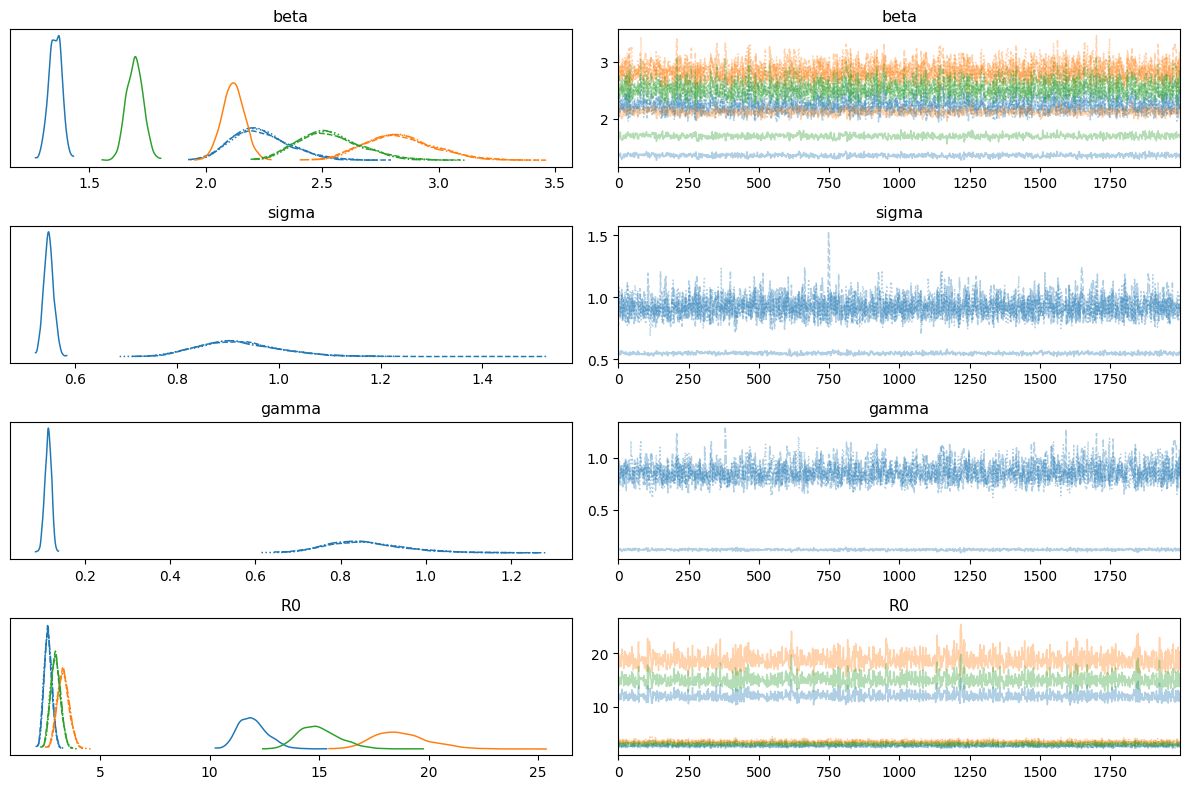

In [76]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)
az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

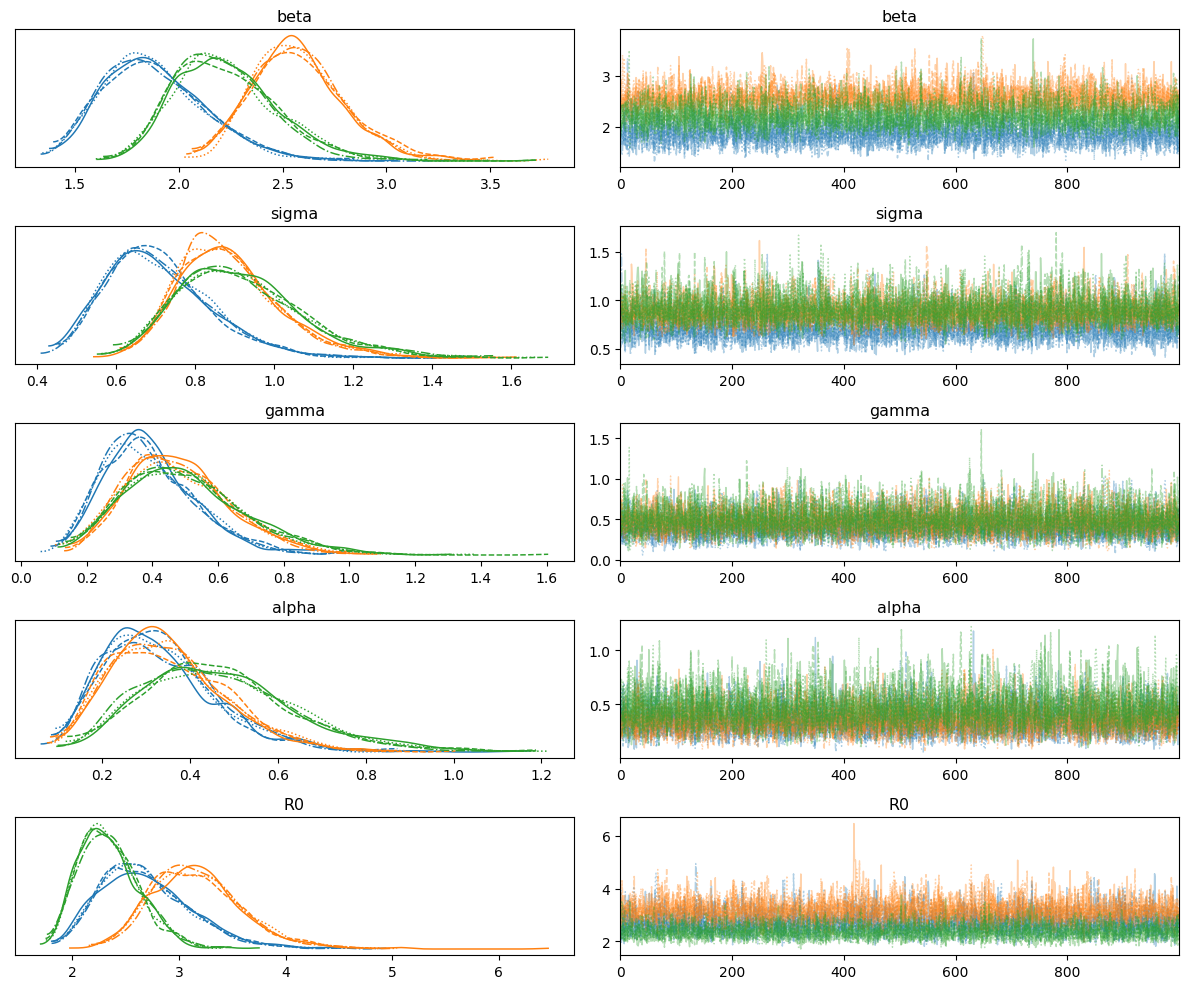

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [77]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = (1/8.5)*7 #incubation rate per week
gamma = (1/13)*7    # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

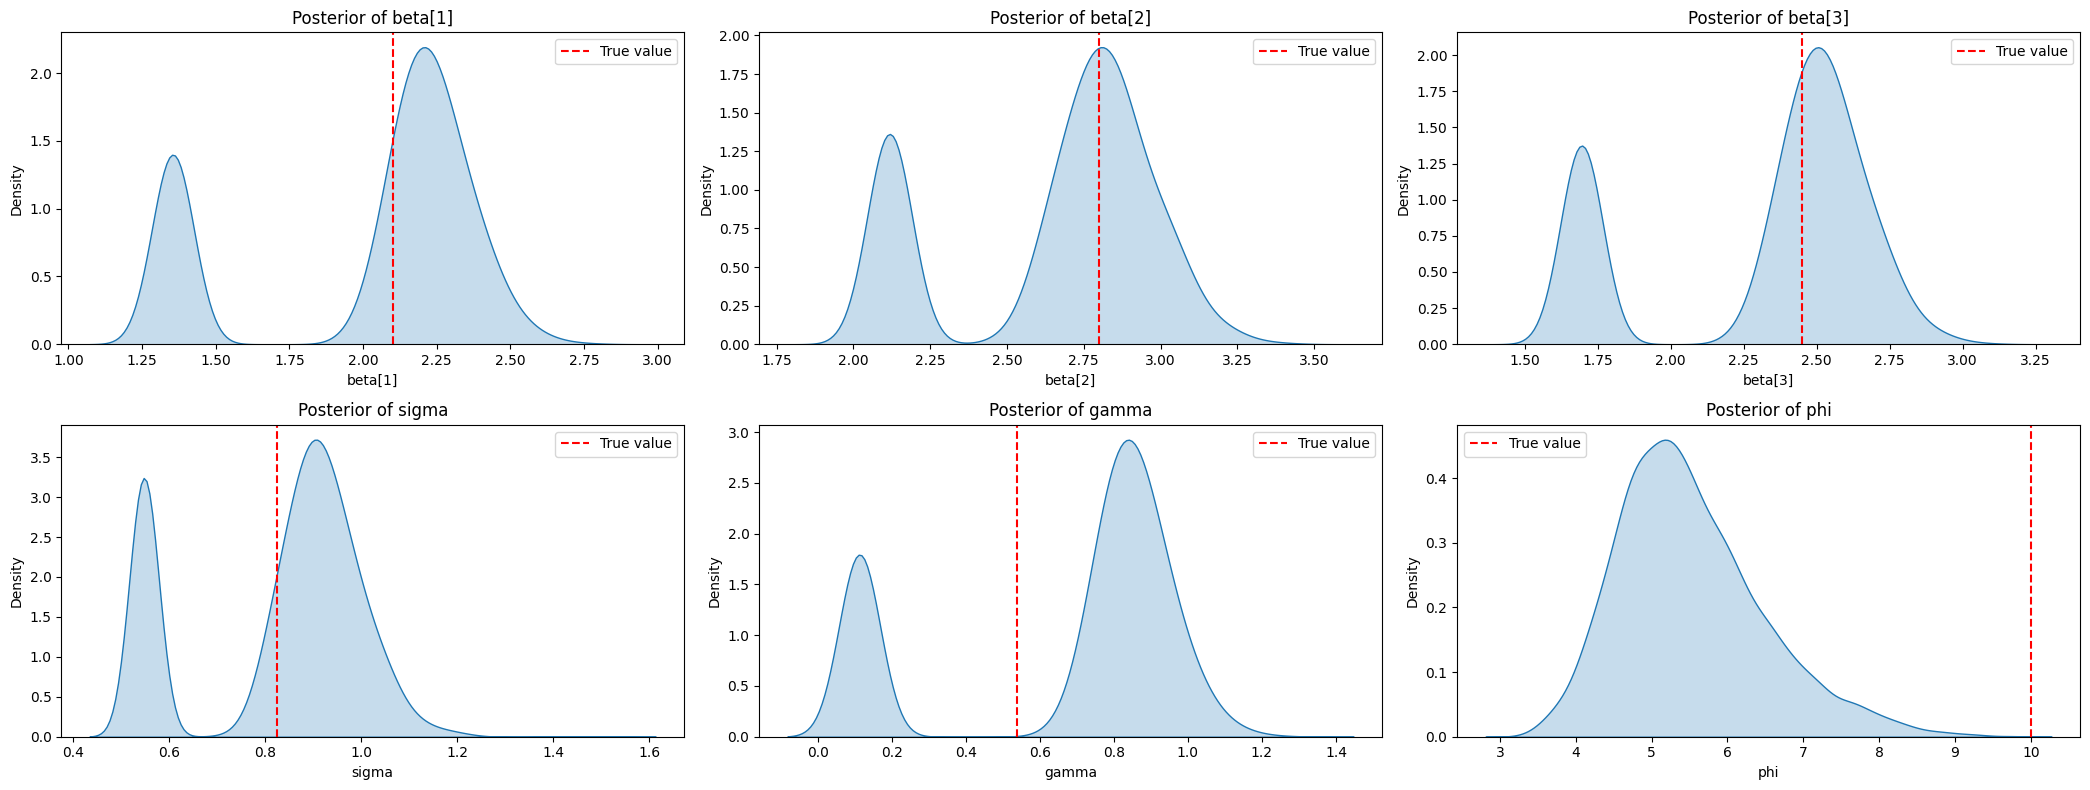

In [78]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma","gamma", 'phi']
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma': sigma, 'gamma': gamma,
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t)

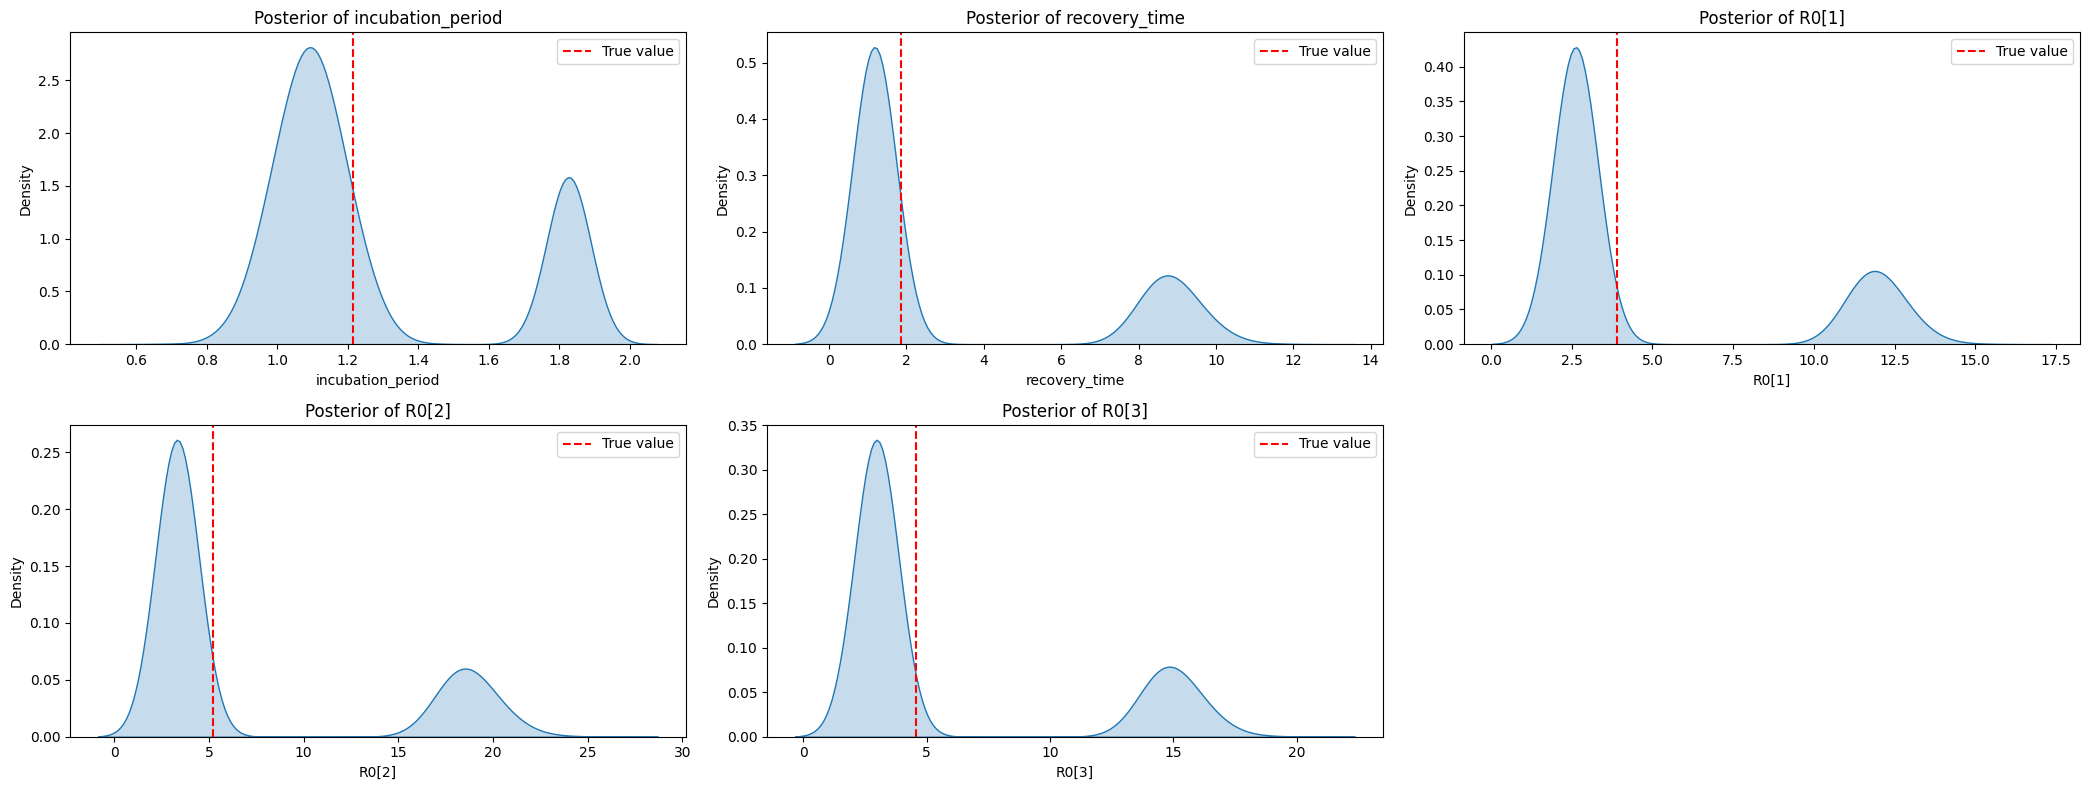

In [79]:
parameters1 = ["incubation_period","recovery_time",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time':rec,
    'incubation_period': incu}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1)

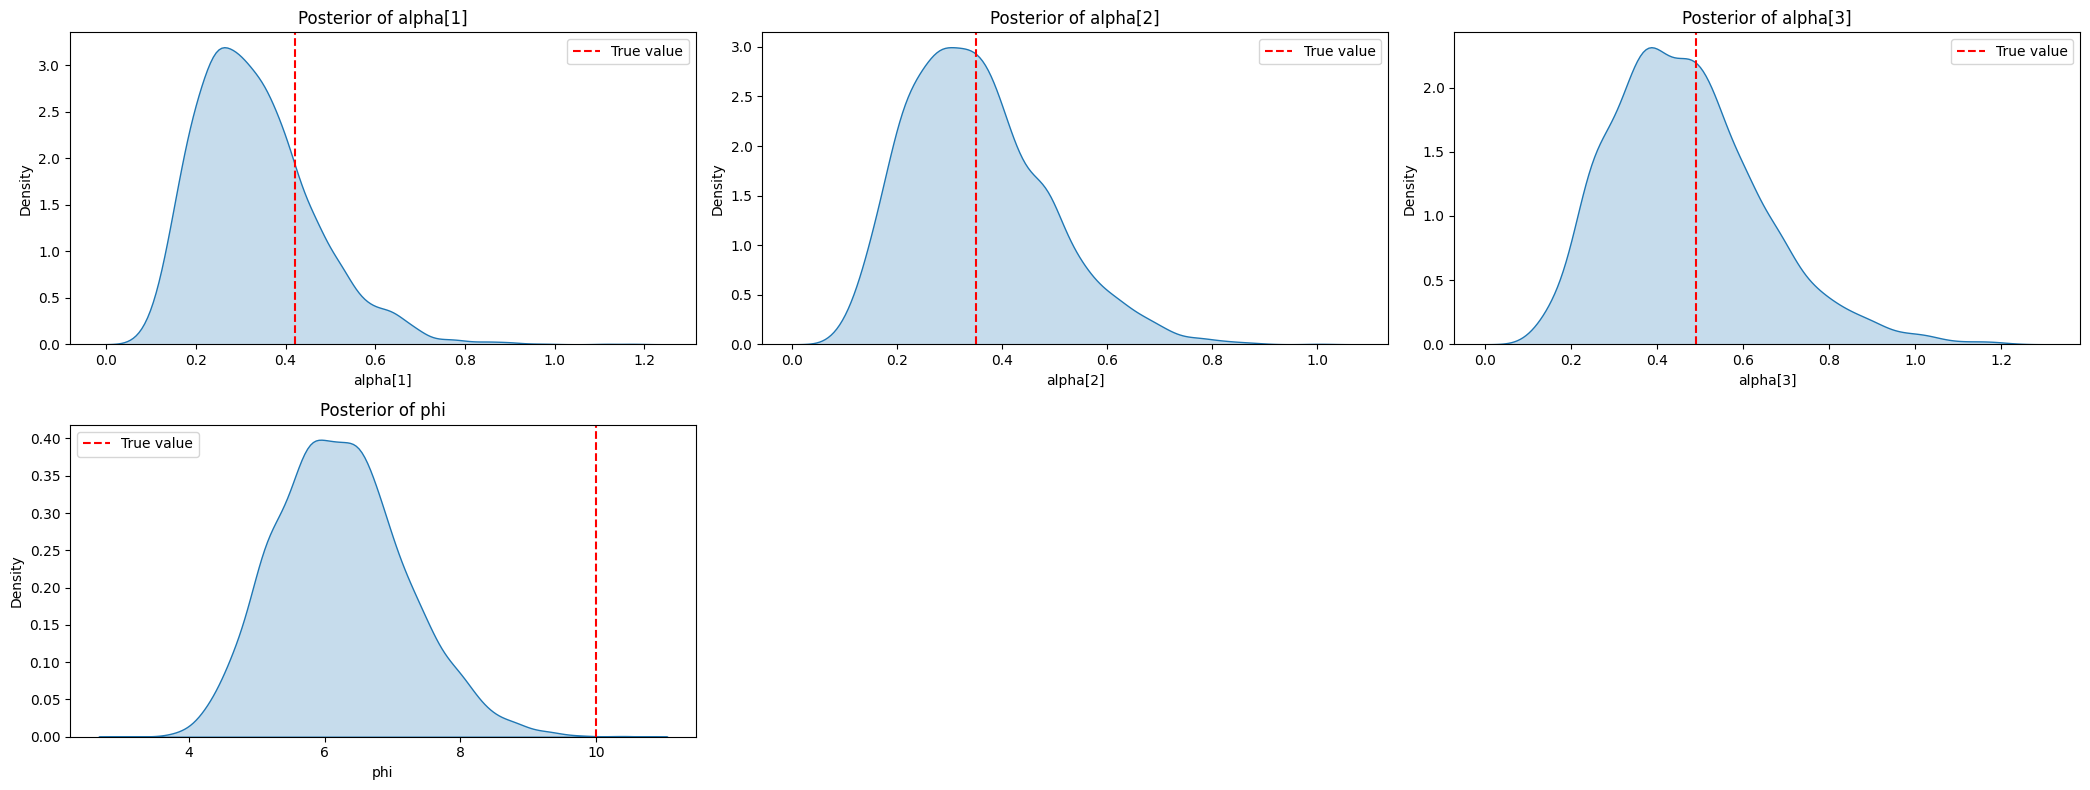

In [ ]:
parameters1 = ['phi']
t1 = {'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


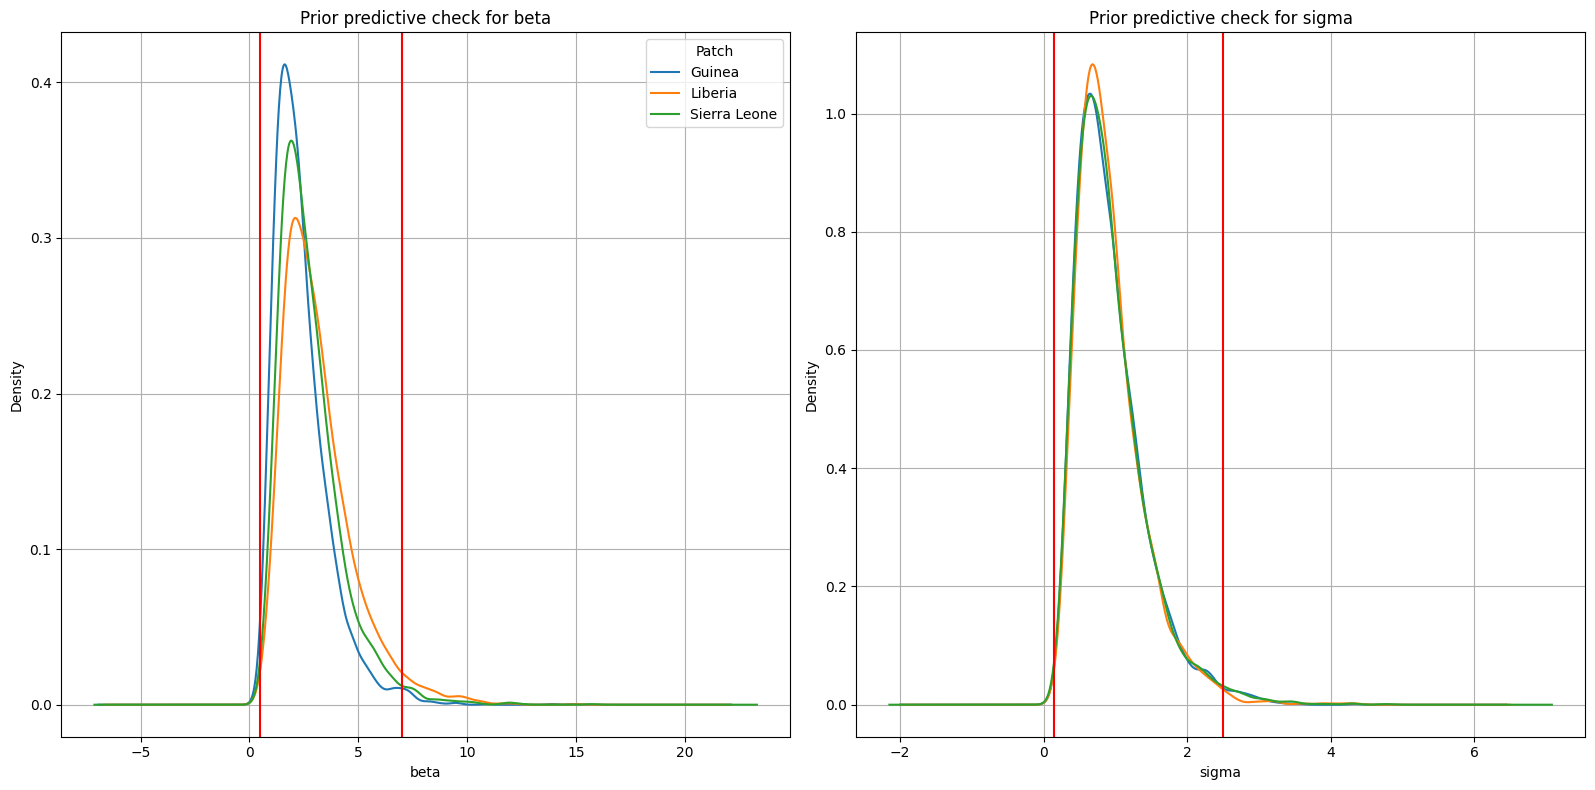

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()